In [1]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
from pathlib import Path
import pyarrow as pa
from collections import Counter
import regionmask
import matplotlib.patheffects as path_effects 
import cartopy.io.shapereader as shpreader
import seaborn as sns
from scipy import stats

# Ticks and Plot Features

In [2]:
import numpy as np

def generate_custom_ticks_1(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = -7.0, 7.0
        
    # 2. Find the largest absolute value to force symmetry around 0
    max_abs = int(np.ceil(max(abs(exact_min), abs(exact_max))))
    
    # Force a minimum symmetric boundary (e.g., if max change is only 1, force a clean map)
    if max_abs == 0: 
        max_abs = 1
        
    # 3. Establish symmetric exact visual boundaries for pcolormesh (vmin / vmax)
    exact_min_sym = -max_abs
    exact_max_sym = max_abs
    
    # 4. Generate whole-number ticks from -max_abs to +max_abs
    # We step by 1 or 2 depending on how wide the span is to keep the colorbar clean
    step = 1
    custom_ticks = list(range(-max_abs, max_abs + 1, step))
    
    # 5. Create clean string labels without decimal points
    tick_labels = [f"{t}" for t in custom_ticks]
    
    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym

In [3]:
import numpy as np

def generate_custom_ticks_05(grid_values):
    # 1. Get exact data limits
    exact_min = np.nanmin(grid_values)
    exact_max = np.nanmax(grid_values)
    
    if np.isnan(exact_min): 
        exact_min, exact_max = 0.0, 2.0
    
    # 2. Round outward to the nearest 0.25 step to establish the uniform grid
    grid_start = np.floor(exact_min * 4) / 4
    grid_end = np.ceil(exact_max * 4) / 4
    
    # 3. Generate the full uniform step array (inclusive of grid_end) with 0.25 step size
    full_grid = np.arange(grid_start, grid_end + 0.125, 0.25)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together middle ticks
    custom_ticks = middle_ticks
    
    # 6. Generate text labels with 2 decimal places (0.00 format)
    tick_labels = [f"{t:.2f}" for t in middle_ticks]
            
    return custom_ticks, tick_labels, exact_max, exact_min

In [4]:
import numpy as np

def generate_custom_ticks_02(grid_values):
    # 1. Get exact data limits
    exact_max = np.nanmax(grid_values)
    
    # 2. Round outward to the nearest 0.5 step to establish the uniform grid
    grid_start = np.floor(-exact_max * 2) / 2
    grid_end = np.ceil(exact_max * 2) / 2
    
    # 3. Generate the full uniform step array (inclusive of grid_end)
    full_grid = np.arange(grid_start, grid_end + 0.1, .1)
    
    # 4. Slice off the fake outer boundaries to leave only the true middle ticks
    middle_ticks = list(full_grid[1:-1])
    
    # 5. Group together: [Exact Min, Middle Ticks..., Exact Max]
    custom_ticks = [-exact_max] + middle_ticks + [exact_max]
    
    # 6. Generate text labels matching the spacing rules
    tick_labels = []
    for t in custom_ticks:
        if t % 1 == 0:
            tick_labels.append(f"{t:.1f}") # Pure whole numbers get no decimals
        else:
            tick_labels.append(f"{t:.1f}")  # Half-steps get 1 decimal place (e.g., 2.5)
            
    return custom_ticks, tick_labels, exact_max, -exact_max

In [5]:

# --- STEP 1: Load Canada and Mexico Geometries once ---
shpfilename = shpreader.natural_earth(resolution='50m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
records = reader.records()

canada_geom = None
mexico_geom = None

for record in records:
    country_name = record.attributes.get('NAME')
    if country_name == 'Canada':
        canada_geom = record.geometry
    elif country_name == 'Mexico':
        mexico_geom = record.geometry

# Load 50m Lakes Shapefile from Natural Earth
lakes_shp = shpreader.natural_earth(resolution='50m', category='physical', name='lakes')
lakes_reader = shpreader.Reader(lakes_shp)

# Names of the Great Lakes to isolate
great_lakes_names = {'Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario'}

# Filter out only the Great Lakes geometries
great_lakes_geoms = []
for record in lakes_reader.records():
    # 'name' is the attribute key for the lake's name in Natural Earth
    lake_name = record.attributes.get('name')
    if lake_name in great_lakes_names:
        great_lakes_geoms.append(record.geometry)

# Use Natural Earth's defined regions for US States (50m resolution)
us_states = regionmask.defined_regions.natural_earth_v5_0_0.us_states_50

# HIST/FTR Thirstwave File

In [6]:
# Define file paths
hist = '/data1/michsh/CSV/HIST_derived_metrics_2.csv'
ftr = '/data1/michsh/CSV/FUT_derived_metrics_2.csv'

# Thirstwave Characteristics HIST/FTR AVG

## Duration

In [7]:
import gc
import numpy as np
import pandas as pd

# Clean up old global variables if re-running in Jupyter
if "hist_dur_events" in globals():
    del hist_dur_events
    gc.collect()

if "ftr_dur_events" in globals():
    del ftr_dur_events
    gc.collect()

# Added 'start_date' (or 'time') to explicitly identify unique temporal events
cols_to_keep = ["AMOC", "member", "lat", "lon", "duration", "start_time"]

# ==========================================
# STEP 1: Process HIST Baseline
# ==========================================
hist_dur_chunks = []
for chunk in pd.read_csv(hist, chunksize=200000, usecols=cols_to_keep):
    # Filter valid durations and drop local duplicates including start_date
    filtered_chunk = chunk[chunk["duration"] > 0].drop_duplicates()
    hist_dur_chunks.append(filtered_chunk)

hist_dur_events = pd.concat(hist_dur_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del hist_dur_chunks
gc.collect()

# Optional: If you don't need start_date for downstream steps, drop it now
# hist_dur_events = hist_dur_events.drop(columns=["start_date"])

# ==========================================
# STEP 2: Process FTR Future
# ==========================================
ftr_dur_chunks = []
for chunk in pd.read_csv(ftr, chunksize=200000, usecols=cols_to_keep):
    filtered_chunk = chunk[chunk["duration"] > 0].drop_duplicates()
    ftr_dur_chunks.append(filtered_chunk)

ftr_dur_events = pd.concat(ftr_dur_chunks, ignore_index=True).drop_duplicates()

# FREE MEMORY: Drop chunk list
del ftr_dur_chunks
gc.collect()

# Optional: Drop start_date here as well
# ftr_dur_events = ftr_dur_events.drop(columns=["start_date"])

0

In [8]:
hist_dur_events

,AMOC,member,lat,lon,start_time,duration
0,1231,1,24.031414,235.0,1850-10-14 00:00:00,5
1,1231,1,24.031414,235.0,1851-04-13 00:00:00,4
2,1231,1,24.031414,235.0,1851-07-13 00:00:00,3
3,1231,1,24.031414,235.0,1851-09-06 00:00:00,4
4,1231,1,24.031414,235.0,1851-10-03 00:00:00,4
...,...,...,...,...,...,...
35159897,1301,20,51.361257,292.5,2012-07-21 00:00:00,6
35159898,1301,20,51.361257,292.5,2012-07-29 00:00:00,3
35159899,1301,20,51.361257,292.5,2014-05-17 00:00:00,4
35159900,1301,20,51.361257,292.5,2014-09-19 00:00:00,3


In [9]:
ftr_dur_events

,AMOC,member,lat,lon,start_time,duration
0,1231,1,24.031414,235.0,2015-05-02 00:00:00,3
1,1231,1,24.031414,235.0,2016-04-18 00:00:00,3
2,1231,1,24.031414,235.0,2016-04-26 00:00:00,4
3,1231,1,24.031414,235.0,2016-05-24 00:00:00,4
4,1231,1,24.031414,235.0,2016-06-19 00:00:00,9
...,...,...,...,...,...,...
56172453,1301,20,51.361257,292.5,2100-08-11 00:00:00,4
56172454,1301,20,51.361257,292.5,2100-08-17 00:00:00,3
56172455,1301,20,51.361257,292.5,2100-08-21 00:00:00,4
56172456,1301,20,51.361257,292.5,2100-09-17 00:00:00,6


In [10]:
hist_member_means = (
    hist_dur_events
    .groupby(['lat', 'lon', 'AMOC', 'member'])['duration']
    .mean()
    .reset_index()
)

ftr_member_means = (
    ftr_dur_events
    .groupby(['lat', 'lon', 'AMOC', 'member'])['duration']
    .mean()
    .reset_index()
)

# --- 3. Calculate the Mean Across the 80 Ensemble Members ---
# Now we average over the 'AMOC' and 'member' dimensions to get one value per grid box.
hist_ensemble_mean_duration = (
    hist_member_means
    .groupby(['lat', 'lon'])['duration']
    .mean()
    .reset_index(name='mean_dur')
)

ftr_ensemble_mean_duration = (
    ftr_member_means
    .groupby(['lat', 'lon'])['duration']
    .mean()
    .reset_index(name='mean_dur')
)

In [11]:
hist_member_means

#112800 

,lat,lon,AMOC,member,duration
0,24.031414,235.0,1231,1,4.258065
1,24.031414,235.0,1231,2,4.174359
2,24.031414,235.0,1231,3,4.114815
3,24.031414,235.0,1231,4,4.272021
4,24.031414,235.0,1231,5,4.207692
...,...,...,...,...,...
112795,51.361257,292.5,1301,16,3.598361
112796,51.361257,292.5,1301,17,3.483254
112797,51.361257,292.5,1301,18,3.583333
112798,51.361257,292.5,1301,19,3.657407


In [12]:
hist_ensemble_mean_duration

# Need to close 
# hist_dur_events
# ftr_dur_events
# hist_member_means
# ftr_member_means
# hist_ensemble_mean_duration
# ftr_ensemble_mean_duration

,lat,lon,mean_dur
0,24.031414,235.00,4.194825
1,24.031414,236.25,4.125054
2,24.031414,237.50,4.079734
3,24.031414,238.75,4.052772
4,24.031414,240.00,4.032528
...,...,...,...
1405,51.361257,287.50,3.744724
1406,51.361257,288.75,3.712066
1407,51.361257,290.00,3.700264
1408,51.361257,291.25,3.653153


In [14]:
import pandas as pd


def get_conus_mask_df(df, us_states_obj):
    """Generates a DataFrame of valid CONUS lat/lon coordinates from a dataset."""
    lats = df["lat"].unique()
    lons = df["lon"].unique()

    # Generate 3D Fractional CONUS Mask & collapse to 2D
    frac_mask_3d = us_states_obj.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Return unique lat/lon pairs inside CONUS
    return (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )


def slice_spatial_box(df, s=None, n=None, w=None, e=None, conus_mask_df=None):
    """Filters a DataFrame by latitude/longitude bounds and/or a CONUS shape mask."""
    # Start with full copy or CONUS-masked subset
    if conus_mask_df is not None:
        filtered_df = pd.merge(
            df, conus_mask_df, on=["lat", "lon"], how="inner"
        )
    else:
        filtered_df = df.copy()

    # If no spatial box bounds are specified, return the current masked DataFrame
    if s is None or n is None or w is None or e is None:
        return filtered_df

    # Apply bounding box filtering for sub-regions
    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (filtered_df["lat"] >= s) & (filtered_df["lat"] <= n)
    lon_mask = ((filtered_df["lon"] >= w_neg) & (filtered_df["lon"] <= e_neg)) | (
        (filtered_df["lon"] >= w_360) & (filtered_df["lon"] <= e_360)
    )

    return filtered_df[lat_mask & lon_mask].copy()


# =========================================================================
# 1. PRE-COMPUTE CONUS MASK
# =========================================================================
# Generate CONUS coordinates grid using historical grid structure
conus_coords_df = get_conus_mask_df(hist_ensemble_mean_duration, us_states)


# =========================================================================
# 2. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
        "use_conus_mask": True,
    },
    {
        "name": "Midwest",
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
        "use_conus_mask": True,  # Set to True if you also want Midwest constrained strictly to CONUS land
    },
    {
        "name": "Northeast",
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
        "use_conus_mask": True,
    },
]


# =========================================================================
# 3. CALCULATE AND PRINT REGIONAL ENSEMBLE MEANS & % CHANGE
# =========================================================================
for reg in regions:
    region_name = reg["name"]
    mask_to_use = conus_coords_df if reg.get("use_conus_mask") else None

    # Slice grid-cell ensemble averages for the region
    hist_reg_df = slice_spatial_box(
        hist_ensemble_mean_duration,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    ftr_reg_df = slice_spatial_box(
        ftr_ensemble_mean_duration,
        reg["lat_s"],
        reg["lat_n"],
        reg["lon_w"],
        reg["lon_e"],
        conus_mask_df=mask_to_use,
    )

    # Calculate scalar spatial mean across grid boxes in the region
    reg_hist_mean = hist_reg_df["mean_dur"].mean()
    reg_ftr_mean = ftr_reg_df["mean_dur"].mean()

    # Calculate absolute difference (Delta) and Percentage Change
    reg_delta_mean = reg_ftr_mean - reg_hist_mean

    reg_pct_change = (
        (reg_delta_mean / reg_hist_mean) * 100 if reg_hist_mean != 0 else 0.0
    )

    # Print summary output for the current region
    print(f"{'='*60}")
    print(f" REGION: {region_name.upper()}")
    print(f"{'='*60}")
    print(
        f"  Historical Ensemble Mean Duration: {reg_hist_mean:.4f} Days"
    )
    print(
        f"  Future Ensemble Mean Duration:     {reg_ftr_mean:.4f} Days"
    )
    print(
        f"  Net Mean Duration Change (Delta):  {reg_delta_mean:+.4f} Days"
    )
    print(f"  Percentage Change:                  {reg_pct_change:+.2f}%\n")

 REGION: CONUS
  Historical Ensemble Mean Duration: 3.7522 Days
  Future Ensemble Mean Duration:     4.3416 Days
  Net Mean Duration Change (Delta):  +0.5894 Days
  Percentage Change:                  +15.71%

 REGION: MIDWEST
  Historical Ensemble Mean Duration: 3.7311 Days
  Future Ensemble Mean Duration:     4.1297 Days
  Net Mean Duration Change (Delta):  +0.3986 Days
  Percentage Change:                  +10.68%

 REGION: NORTHEAST
  Historical Ensemble Mean Duration: 3.5558 Days
  Future Ensemble Mean Duration:     4.3436 Days
  Net Mean Duration Change (Delta):  +0.7878 Days
  Percentage Change:                  +22.16%



# Duration: CONUS AVG

In [13]:
masked_data_arrays = []
for df in [hist_ensemble_mean_duration, ftr_ensemble_mean_duration]:
    # Extract coordinates
    lats = df['lat'].unique()
    lons = df['lon'].unique()
    
    # 1. Calculate the fractional overlap of each grid cell with the US States.
    # We pass the 1D lat/lon coordinates directly to the fractional mask generator
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)
    
    # 2. Collapse the 'region' dimension by checking if a cell overlaps with ANY US State.
    # We set the threshold to > 0 to keep any cell that touches or sits on the border.
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")
    
    # 3. Pivot dataframe to apply spatial mask
    pivoted = df.pivot(index='lat', columns='lon', values='mean_dur')
    
    # 4. Mask the pivoted data using our fractional boolean mask
    # (Because any_overlap_mask is an xarray DataArray, we extract its values using .values)
    pivoted_masked = pivoted.where(any_overlap_mask.values)
    
    # 5. Flatten/melt back into the clean flat DataFrame format
    flat_masked = (
        pivoted_masked
        .stack(dropna=True) # Drops all grid coordinates outside CONUS
        .reset_index(name='mean_dur')
    )
    masked_data_arrays.append(flat_masked)

hist_ensemble_mean_duration_masked, ftr_ensemble_mean_duration_masked = masked_data_arrays

/tmp/ipykernel_1143810/3644274810.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pivoted_masked
/tmp/ipykernel_1143810/3644274810.py:24: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pivoted_masked


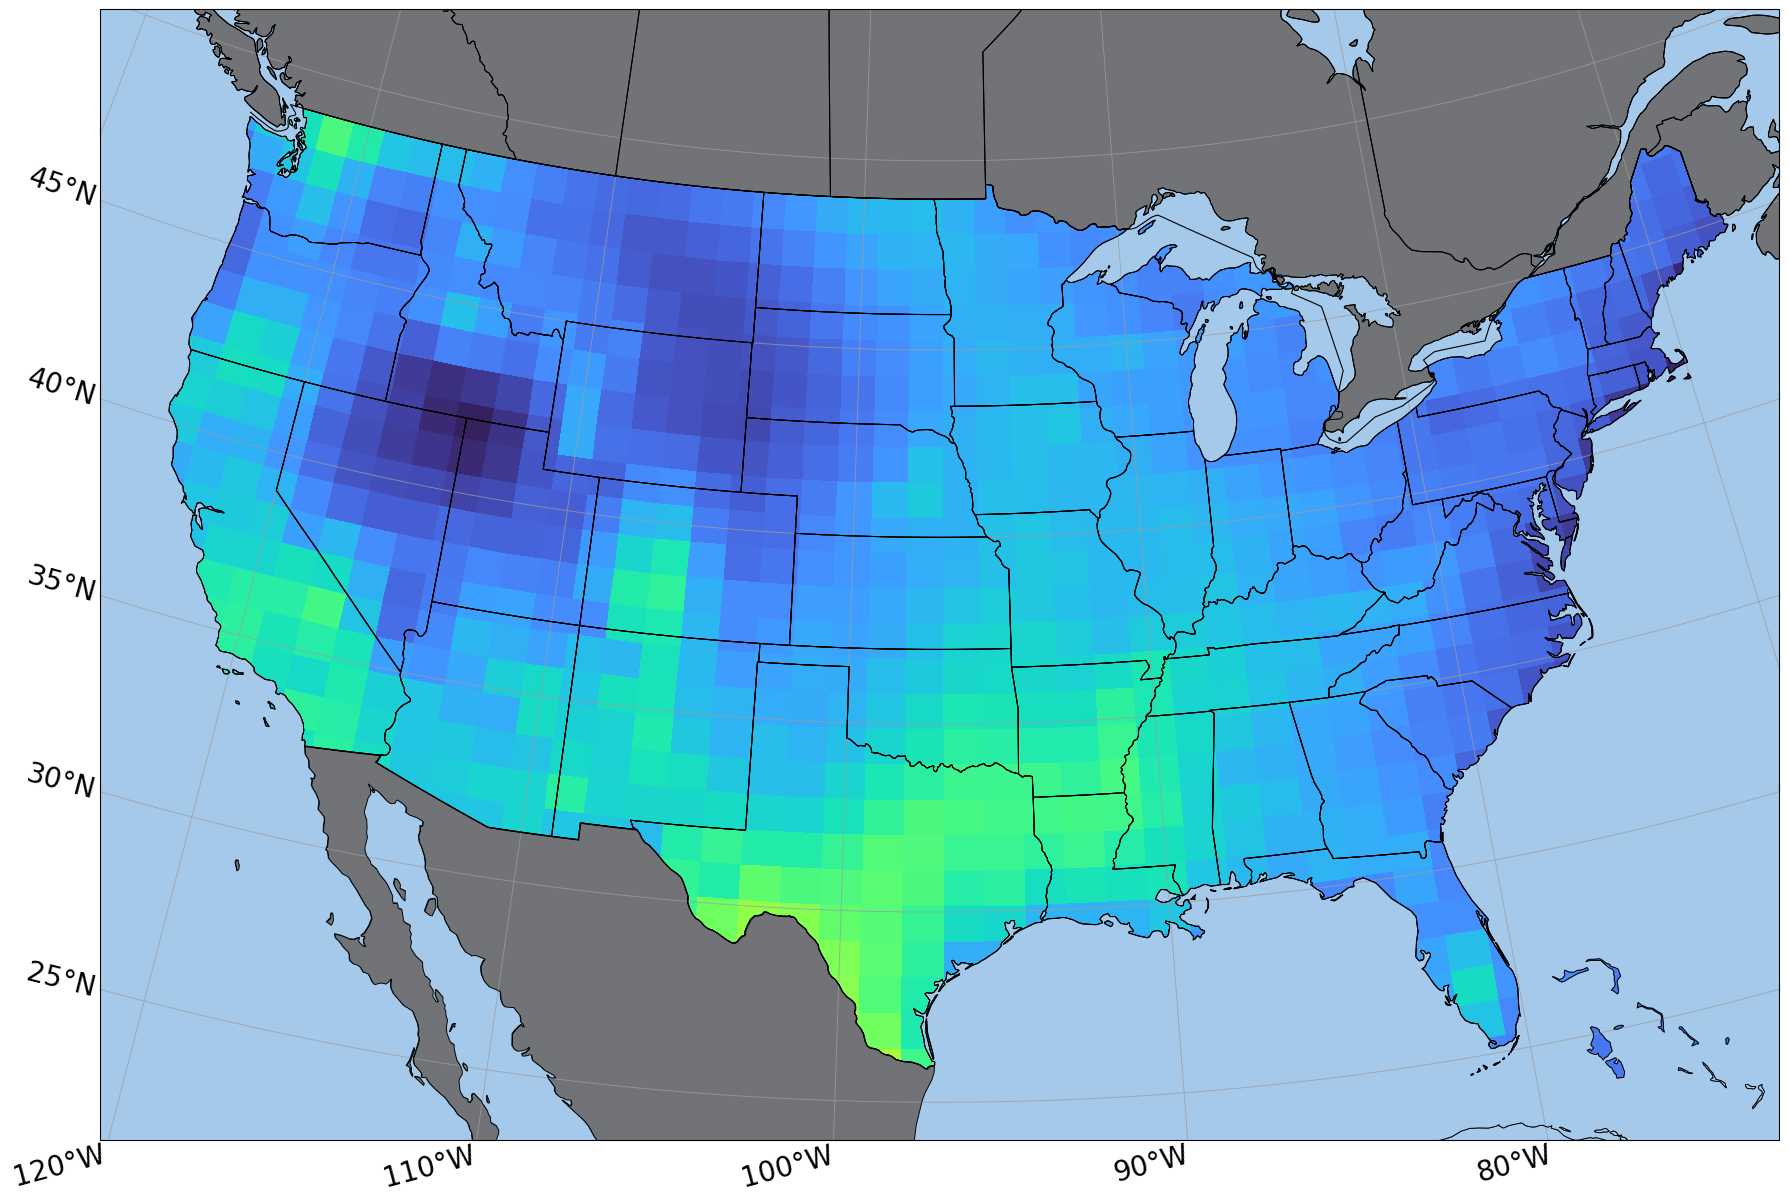

In [14]:
# Reassign masked datasets
hist_conus_mean_masked, ftr_conus_mean_masked = masked_data_arrays

data_arrays = [hist_ensemble_mean_duration]

global_min = min(hist_conus_mean_masked['mean_dur'].min(), ftr_conus_mean_masked['mean_dur'].min())
global_max = max(hist_conus_mean_masked['mean_dur'].max(), ftr_conus_mean_masked['mean_dur'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for array in data_arrays: 
    plot_target_da = array  

    if plot_target_da is hist_ensemble_mean_duration:
        title = "Historical Thirstwave Duration | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Duration_Mean_HIST'
    elif plot_target_da is ftr_ensemble_mean_duration:
        title = "Future Thirstwave Duration | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Duration_Mean_FTR'

    # This transforms the flat DataFrame into a clean 2D grid of values
    grid_data_dur = (
        plot_target_da
        .pivot(index='lat', columns='lon', values='mean_dur')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid_data_dur.columns, grid_data_dur.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid_data_dur.values, 
                        transform=ccrs.PlateCarree(), 
                        cmap='turbo', # <==================================================================== COLORTABLE
                        vmin=exact_min, vmax=exact_max, 
                        shading='auto',
                        zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                            facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                            facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                            facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                        color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    # ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    # ax_box.set_facecolor('white')
    # ax_box.set_xticks([])
    # ax_box.set_yticks([])
    # for spine in ax_box.spines.values():
    #     spine.set_visible(True)
    #     spine.set_edgecolor('black')
    #     spine.set_linewidth(1.0)

    # # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    # cax = ax_box.inset_axes([0.10, 0.04, 0.44, 0.84]) 

    # # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    # cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # # Style the colorbar ticks & tick labels
    # cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    # cb.ax.tick_params(direction='out', length=4, width=1)

    # # --- ADDED: Text Title inside the White Box ---
    # # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    # ax_box.text(
    #     0.5, 0.94, 
    #     "Days", 
    #     transform=ax_box.transAxes, 
    #     fontsize=20, 
    #     weight='bold', 
    #     color='black',
    #     ha='center', 
    #     va='center'
    # )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

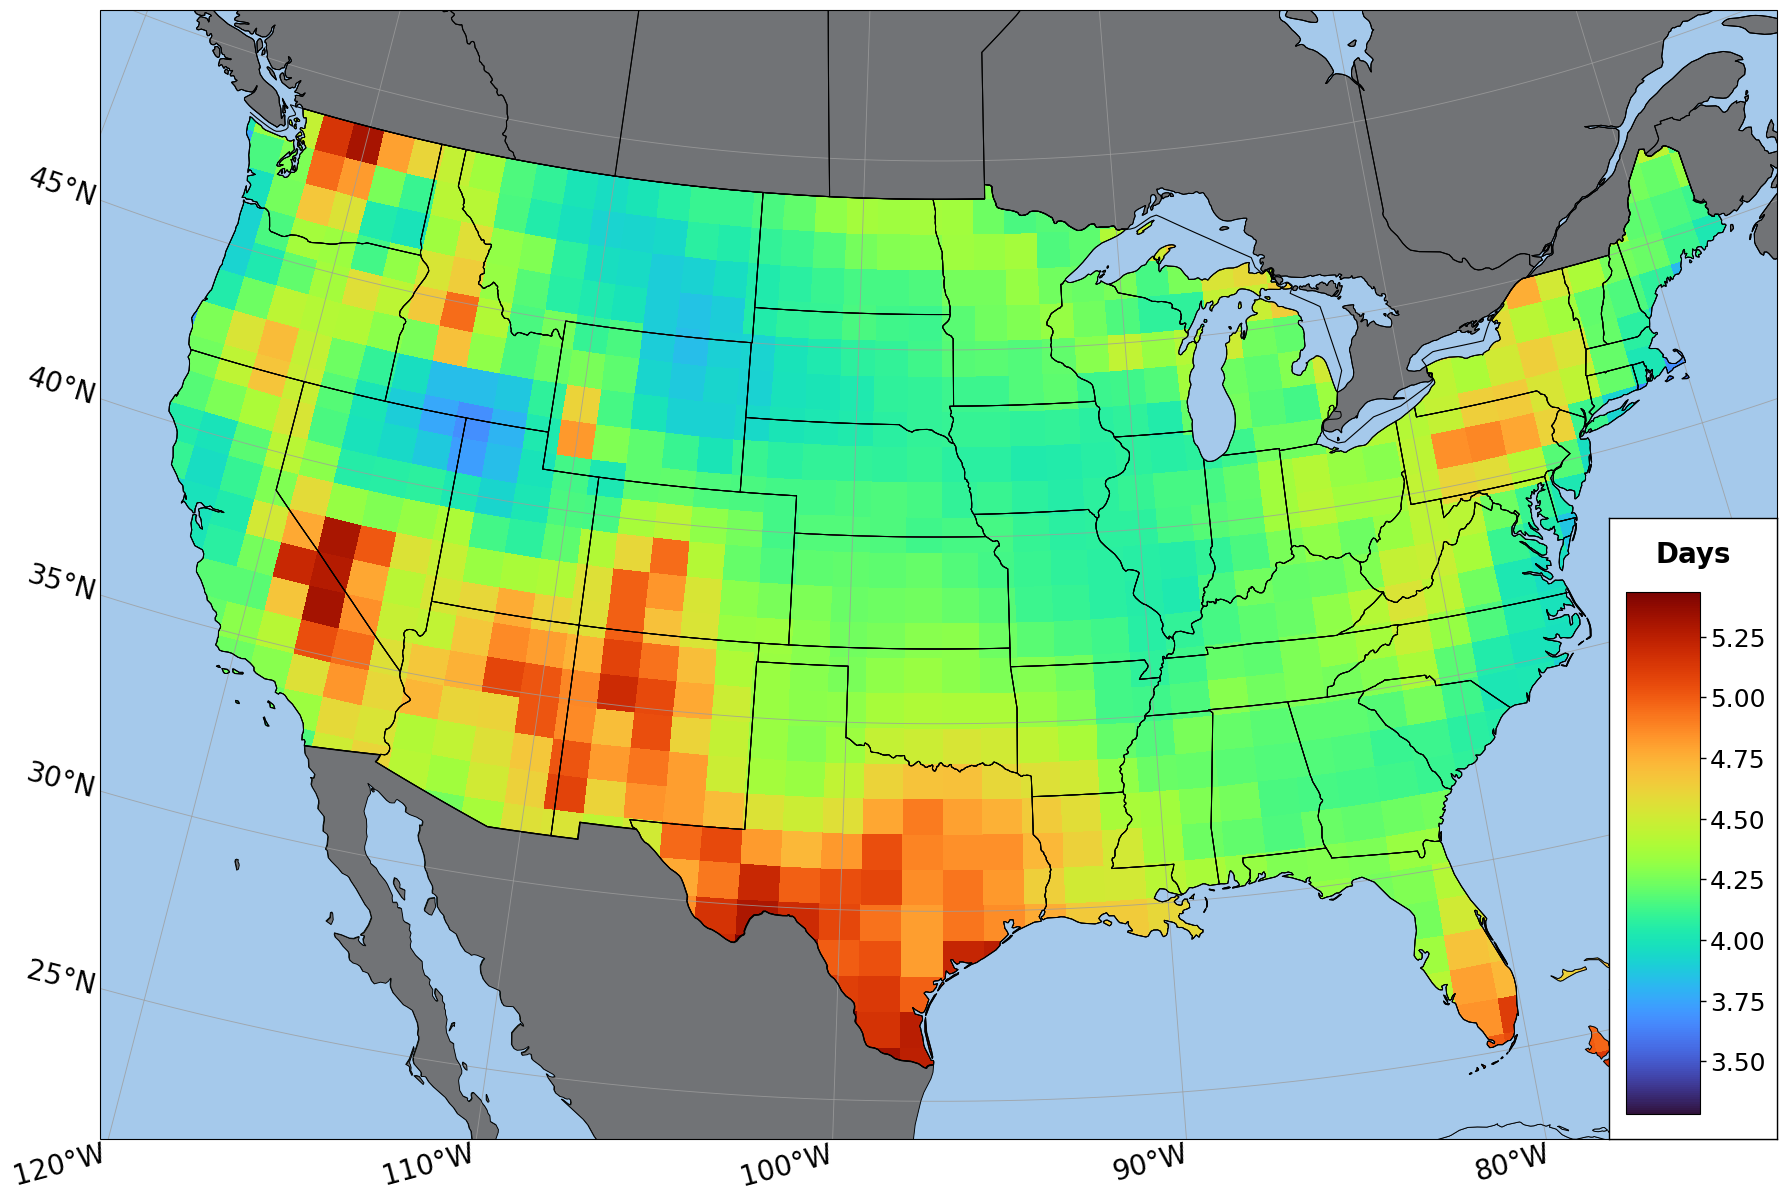

In [15]:
# Reassign masked datasets
hist_conus_mean_masked, ftr_conus_mean_masked = masked_data_arrays

data_arrays = [ftr_ensemble_mean_duration]

global_min = min(hist_conus_mean_masked['mean_dur'].min(), ftr_conus_mean_masked['mean_dur'].min())
global_max = max(hist_conus_mean_masked['mean_dur'].max(), ftr_conus_mean_masked['mean_dur'].max())

combined_min_max_grid = np.array([global_min, global_max])
custom_ticks, tick_labels, exact_max, exact_min = generate_custom_ticks_05(combined_min_max_grid)

for array in data_arrays: 
    plot_target_da = array  

    if plot_target_da is hist_ensemble_mean_duration:
        title = "Historical Thirstwave Duration | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Duration_Mean_HIST'
    elif plot_target_da is ftr_ensemble_mean_duration:
        title = "Future Thirstwave Duration | 80-Member Ensemble Mean"
        cb_label = "Days"
        save_name = 'Duration_Mean_FTR'

    # This transforms the flat DataFrame into a clean 2D grid of values
    grid_data_dur = (
        plot_target_da
        .pivot(index='lat', columns='lon', values='mean_dur')
        .sort_index(ascending=True)         # Sort Latitudes monotonically
        .sort_index(axis=1, ascending=True) # Sort Longitudes monotonically
    )

    # Create Meshgrid from sorted 1D coordinates
    X, Y = np.meshgrid(grid_data_dur.columns, grid_data_dur.index)

    s_lat, n_lat = 24, 52
    w_lon, e_lon = -121, -73

    crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

    fig = plt.figure(figsize=(18, 16))
    ax = plt.axes(projection=crs)

    # Set map boundaries
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    water_color = '#a5c9eb'  # Soft pastel blue
    ax.set_facecolor(water_color)  

    im = ax.pcolormesh(X, Y, grid_data_dur.values, 
                        transform=ccrs.PlateCarree(), 
                        cmap='turbo', # <==================================================================== COLORTABLE
                        vmin=exact_min, vmax=exact_max, 
                        shading='auto',
                        zorder=1)

    if canada_geom is not None:
        ax.add_geometries([canada_geom], crs=ccrs.PlateCarree(), 
                            facecolor='#717376', edgecolor='black', linewidth=0.65, zorder=2)
    if mexico_geom is not None:
        ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(), 
                            facecolor="#717376", edgecolor='black', linewidth=0.65, zorder=2)
    if great_lakes_geoms:
        ax.add_geometries(great_lakes_geoms, crs=ccrs.PlateCarree(),
                            facecolor=water_color, edgecolor='black', linewidth=0.65, zorder=2)

    # USA outer outline
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor=water_color, zorder=2)
    ax.coastlines('50m', linewidth=0.65, color='black', zorder=3)

    # USA outer outline
    usa_outline = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=0.8
    )
    ax.add_feature(usa_outline, zorder=3)

    # US State Boundaries
    states = cfeature.NaturalEarthFeature(
        category='cultural', 
        name='admin_1_states_provinces_lakes', 
        scale='50m', 
        facecolor='none'
    )
    ax.add_feature(states, edgecolor='black', linewidth=0.75, zorder=3)

    # Map features
    ax.coastlines('50m', linewidth=0.65)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.65)

        # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.65, 
                        color="#9d9d9d", zorder= 4, alpha=0.8)

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # --- ADDED: Set padding (in points) between labels and the map frame ---
    gl.xpadding = 4  # Adds space for bottom (longitude) labels
    gl.ypadding = 4  # Adds space for left (latitude) labels

    # Style the labels (removed the non-standard 'pad' key)
    gl.xlabel_style = {'size': 20, 'color': 'black', 'rotation': 15}
    gl.ylabel_style = {'size': 20, 'color': 'black'}

    # Force clean tick intervals
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))
    
    ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=5)
    ax_box.set_facecolor('white')
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    for spine in ax_box.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

    # Adjusted to end at y=0.78, leaving the top 22% of the white box for the title
    # Pushed to x=0.20 to leave plenty of room on the right side for tick labels
    cax = ax_box.inset_axes([0.10, 0.04, 0.44, 0.84]) 

    # Plot vertical colorbar (Notice: cb.ax.set_title was removed!)
    cb = plt.colorbar(im, cax=cax, orientation='vertical', ticks=custom_ticks) 

    # Style the colorbar ticks & tick labels
    cb.ax.set_yticklabels(tick_labels, fontsize=18, color='black')
    cb.ax.tick_params(direction='out', length=4, width=1)

    # --- ADDED: Text Title inside the White Box ---
    # Centered at x=0.5 (middle of the box) and y=0.89 (near the top)
    ax_box.text(
        0.5, 0.94, 
        "Days", 
        transform=ax_box.transAxes, 
        fontsize=20, 
        weight='bold', 
        color='black',
        ha='center', 
        va='center'
    )

    # Title & Layout rendering
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()  

# Duration: Pooled T-Test + Delta 

In [16]:
from scipy import stats

# ==========================================
# STEP 1: Grid-by-Grid Loop across Ensemble Members
# ==========================================
# Extract unique spatial grid boxes from duration data
dur_gridboxes = hist_member_means[["lat", "lon"]].drop_duplicates()
dur_results = []

for row in dur_gridboxes.itertuples():
    lat = row.lat
    lon = row.lon

    # Extract all ~80 ensemble members (AMOC x member) for this specific lat/lon
    dur_hist_subset = hist_member_means[
        (hist_member_means.lat == lat) & (hist_member_means.lon == lon)
    ]
    dur_ftr_subset = ftr_member_means[
        (ftr_member_means.lat == lat) & (ftr_member_means.lon == lon)
    ]

    dur_hist_values = dur_hist_subset["duration"].values
    dur_ftr_values = dur_ftr_subset["duration"].values

    # Run independent t-test across ensemble members
    dur_t_stat, dur_p_value = stats.ttest_ind(
        dur_ftr_values,
        dur_hist_values,
        equal_var=True,
        alternative="greater",  # Testing if FTR duration > HIST duration
        nan_policy="omit",
    )

    # Calculate difference between future ensemble mean and historical ensemble mean
    dur_delta_value = np.nanmean(dur_ftr_values) - np.nanmean(dur_hist_values)

    dur_results.append([lat, lon, dur_p_value, dur_delta_value])

# Create flat DataFrame of raw results
dur_results_df = pd.DataFrame(
    dur_results, columns=["lat", "lon", "p_value", "delta"]
)

# ==========================================
# STEP 2: Pivot into Lat x Lon Matrices
# ==========================================
dur_p_values_grid = dur_results_df.pivot(
    index="lat", columns="lon", values="p_value"
)
dur_delta_grid = dur_results_df.pivot(
    index="lat", columns="lon", values="delta"
)

# ==========================================
# STEP 3: Apply CONUS Spatial Mask
# ==========================================
dur_lats = dur_p_values_grid.index.values
dur_lons = dur_p_values_grid.columns.values

frac_mask_3d = us_states.mask_3D_frac_approx(dur_lons, dur_lats, wrap_lon=True)
any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

# Mask both duration matrices to CONUS
dur_p_values_mask = dur_p_values_grid.where(any_overlap_mask.values)
dur_delta_mask = dur_delta_grid.where(any_overlap_mask.values)

# ==========================================
# STEP 4: Unstack & Summarize Results
# ==========================================
# Flat DataFrames ready for plotting or exporting
dur_p_values_conus_flat = (
    dur_p_values_mask.stack(future_stack=True)
    .dropna()
    .reset_index(name="p_value")
)

dur_delta_conus_flat = (
    dur_delta_mask.stack(future_stack=True)
    .dropna()
    .reset_index(name="delta")
)

# Percentage of CONUS grid cells with statistically significant increase in duration (p < 0.05)
total_conus_cells = dur_p_values_mask.notna().sum().sum()
significant_conus_cells = (dur_p_values_mask < 0.05).sum().sum()

sig_pct_dur = (significant_conus_cells / total_conus_cells) * 100
print(
    f"Percentage of CONUS showing significant duration increase (p < 0.05): {sig_pct_dur:.2f}%"
)

Percentage of CONUS showing significant duration increase (p < 0.05): 100.00%


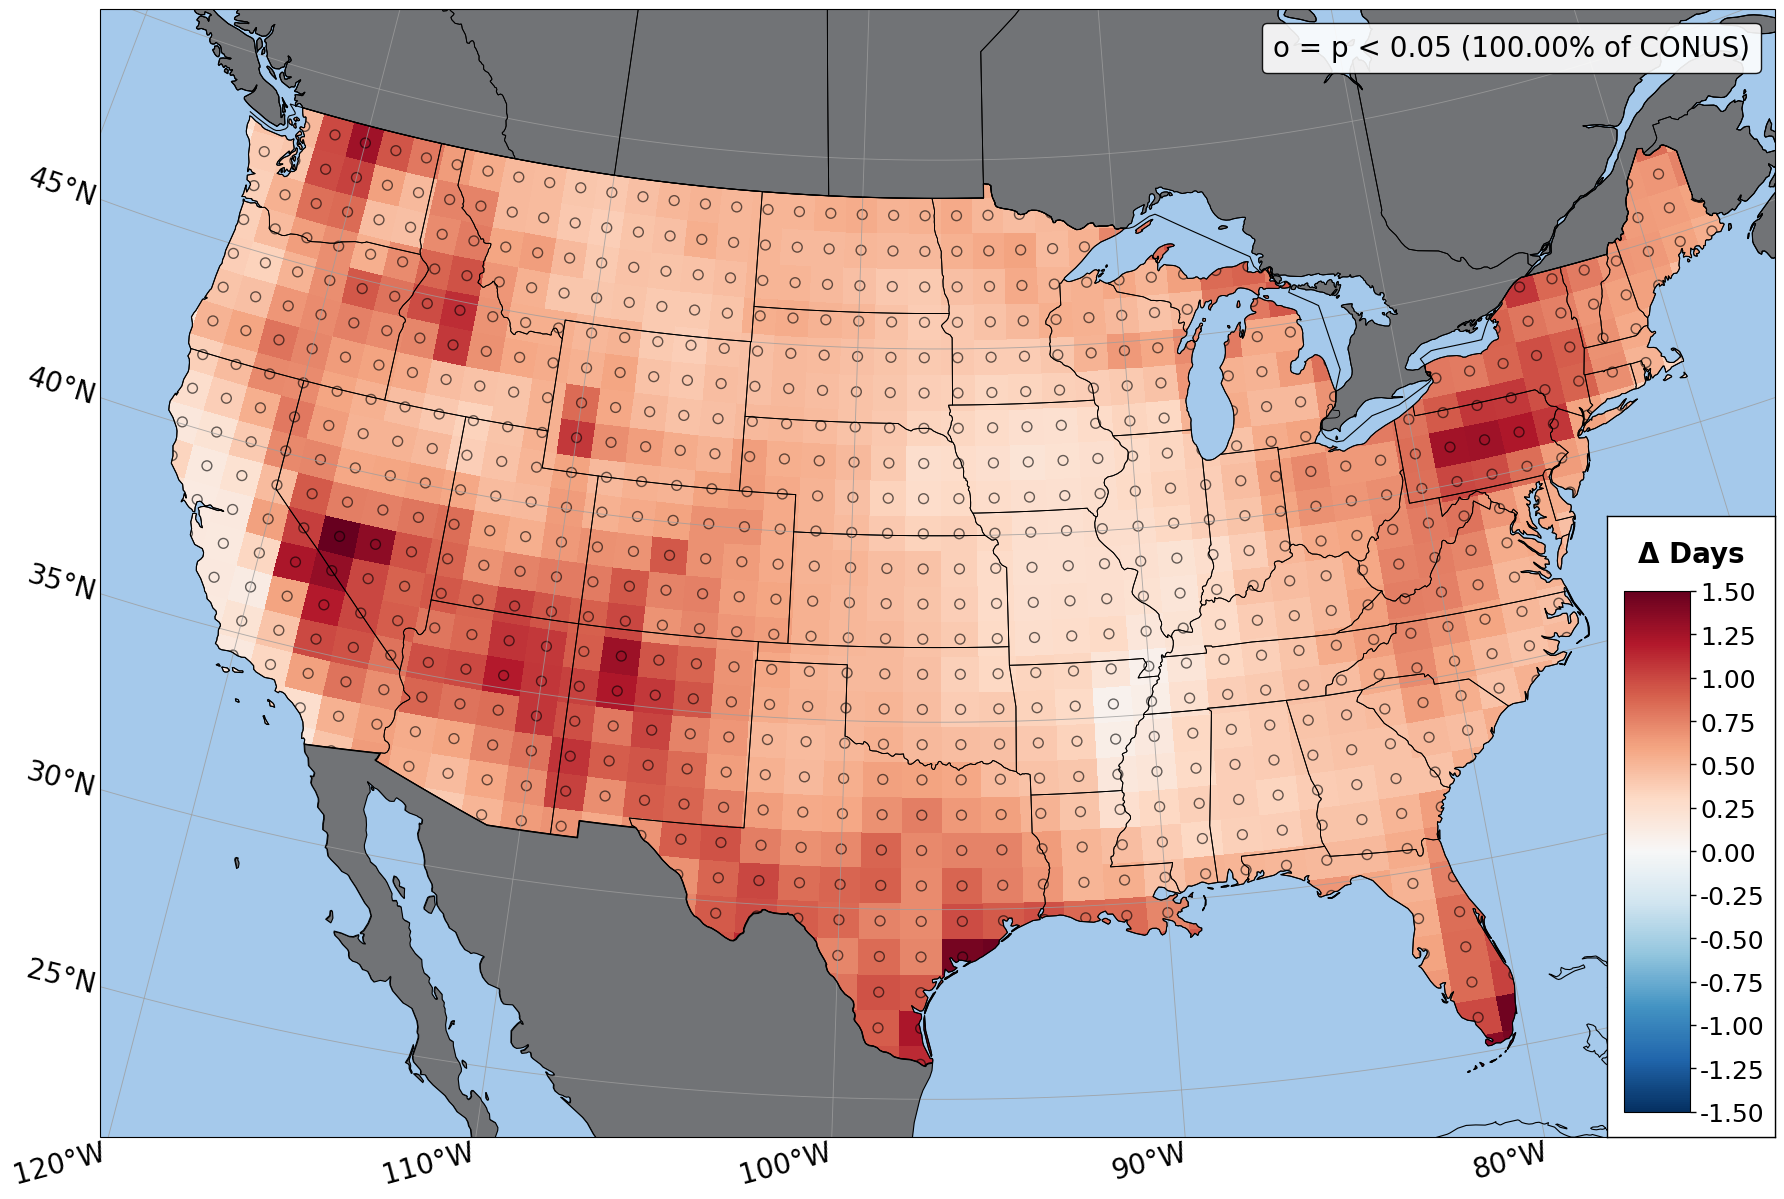

In [17]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D


def generate_custom_ticks_05(grid_values, step=0.5):
    """Computes exact data min/max within CONUS, symmetric limits for pcolormesh,

    and ticks spaced by the step size (default 0.5).
    """
    exact_min = float(np.nanmin(grid_values))
    exact_max = float(np.nanmax(grid_values))

    if np.isnan(exact_min):
        exact_min, exact_max = -1.0, 1.0

    # Symmetric limits rounded up to the nearest multiple of 'step'
    max_abs = np.ceil(max(abs(exact_min), abs(exact_max)) / step) * step
    if max_abs == 0:
        max_abs = step

    exact_min_sym = -max_abs
    exact_max_sym = max_abs

    # Generate potential ticks based on step increment across full symmetric range
    num_steps = int(np.round((exact_max_sym - exact_min_sym) / step)) + 1
    custom_ticks = np.round(np.linspace(exact_min_sym, exact_max_sym, num_steps), 2)

    # Ensure 0.0 is explicitly included and clean up float precision
    custom_ticks = sorted(list(np.unique(np.round(custom_ticks, 2))))
    tick_labels = [f"{t:.2f}" for t in custom_ticks]

    return custom_ticks, tick_labels, exact_max_sym, exact_min_sym


# ==========================================
# 1. Color Bar Ticks Settings (Duration)
# ==========================================
dur_CONUS_max = np.nanmax(np.abs(dur_delta_mask.values))
dur_CONUS_min = -dur_CONUS_max

combined_min_max_grid = np.array([dur_CONUS_min, dur_CONUS_max])
(
    custom_ticks,
    tick_labels,
    exact_max,
    exact_min,
) = generate_custom_ticks_05(combined_min_max_grid, step=0.25)

alpha = 0.05

# ==========================================
# 2. Statistically Significant Gridcells Mask
# ==========================================
# Identifies grid cells where duration increased significantly (p < 0.05)
stat_sig_mask = (dur_p_values_mask < alpha) & (dur_delta_mask > 0)

# Calculate percentage of CONUS experiencing significant duration increase
total_conus_cells = dur_p_values_mask.notna().sum().sum()
significant_conus_cells = stat_sig_mask.sum().sum()

sig_pct = (significant_conus_cells / total_conus_cells) * 100

# ==========================================
# 3. Coordinate Grids & Extracted Stippling Points
# ==========================================
X, Y = np.meshgrid(dur_delta_mask.columns, dur_delta_mask.index)

# Extract coordinates for stippling where stat_sig_mask is True
sig_y_indices, sig_x_indices = np.where(stat_sig_mask.values)
significant_lats = dur_delta_mask.index[sig_y_indices]
significant_lons = dur_delta_mask.columns[sig_x_indices]

# ==========================================
# 4. Figure & Projection Setup
# ==========================================
s_lat, n_lat = 24, 52
w_lon, e_lon = -121, -73

crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)

fig = plt.figure(figsize=(18, 16))
ax = plt.axes(projection=crs)

# Set map boundaries
ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())

water_color = "#a5c9eb"
ax.set_facecolor(water_color)

# Plot the duration delta background field
im = ax.pcolormesh(
    X,
    Y,
    dur_delta_mask.values,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=exact_min,
    vmax=exact_max,
    shading="auto",
    zorder=1,
)

# Geographic overlays
if canada_geom is not None:
    ax.add_geometries(
        [canada_geom],
        crs=ccrs.PlateCarree(),
        facecolor="#717376",
        edgecolor="black",
        linewidth=0.8,
        zorder=2,
    )
if mexico_geom is not None:
    ax.add_geometries(
        [mexico_geom],
        crs=ccrs.PlateCarree(),
        facecolor="#717376",
        edgecolor="black",
        linewidth=0.8,
        zorder=2,
    )
if great_lakes_geoms:
    ax.add_geometries(
        great_lakes_geoms,
        crs=ccrs.PlateCarree(),
        facecolor=water_color,
        edgecolor="black",
        linewidth=0.75,
        zorder=2,
    )

ax.add_feature(
    cfeature.OCEAN.with_scale("50m"), facecolor=water_color, zorder=2
)
ax.coastlines("50m", linewidth=0.8, color="black", zorder=4)

# USA outer outline
usa_outline = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)
ax.add_feature(usa_outline, zorder=3)

# US State Boundaries
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lakes",
    scale="50m",
    facecolor="none",
)
ax.add_feature(states, edgecolor="black", linewidth=0.65, zorder=4)

# Gridlines styling
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.65,
    color="#9d9d9d",
    alpha=0.8,
    zorder=5,
)

gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.x_inline = False
gl.y_inline = False
gl.xpadding = 4
gl.ypadding = 4

gl.xlabel_style = {"size": 20, "color": "black", "rotation": 15}
gl.ylabel_style = {"size": 20, "color": "black"}

gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

# ==========================================
# 5. Significance Legend
# ==========================================
legend_label = f"o = p < 0.05 ({sig_pct:.2f}% of CONUS)"

proxy_handle = Line2D(
    [0],
    [0],
    color="none",
    linestyle="none",
    marker="none",
    label=legend_label,
)

leg = ax.legend(
    handles=[proxy_handle],
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="black",
    fontsize=20,
    handlelength=0,
    handletextpad=0,
)
leg.set_zorder(6)

# ==========================================
# 6. Colorbar Inset Box Setup
# ==========================================
ax_box = ax.inset_axes([0.90, 0, 0.10, 0.55], zorder=6)
ax_box.set_facecolor("white")
ax_box.set_xticks([])
ax_box.set_yticks([])
for spine in ax_box.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

cax = ax_box.inset_axes([0.10, 0.04, 0.39, 0.84])
cb = plt.colorbar(im, cax=cax, orientation="vertical", ticks=custom_ticks)

cb.ax.set_yticklabels(tick_labels, fontsize=18, color="black")
cb.ax.tick_params(direction="out", length=4, width=1)

# Inset box title (Duration specific unit)
ax_box.text(
    0.5,
    0.94,
    "Δ Days",
    transform=ax_box.transAxes,
    fontsize=20,
    weight="bold",
    color="black",
    ha="center",
    va="center",
)

# ==========================================
# 7. Significance Stippling Overlay
# ==========================================
ax.scatter(
    significant_lons,
    significant_lats,
    transform=ccrs.PlateCarree(),
    s=50,
    marker="o",
    facecolors="none",
    edgecolors="black",
    alpha=0.6,
    zorder=1,
)

# Layout rendering & output
plt.tight_layout()

plt.savefig("Duration_Mean_Delta_005.png", dpi=300, bbox_inches="tight")
plt.show()

# Duration: Histograms

In [18]:
# ==============================================================================
# Pre-Histogram Processing for Event Durations (CONUS Masking)
# ==============================================================================

masked_dur_arrays = []

# Process both datasets directly from the loaded event DataFrames
duration_datasets = [hist_dur_events, ftr_dur_events]

for df_dur in duration_datasets:
    # -------------------------------------------------------------------------
    # STEP 1: Extract Spatial Coordinates
    # -------------------------------------------------------------------------
    lats = df_dur["lat"].unique()
    lons = df_dur["lon"].unique()

    # -------------------------------------------------------------------------
    # STEP 2: Generate 3D Fractional CONUS Mask
    # -------------------------------------------------------------------------
    frac_mask_3d = us_states.mask_3D_frac_approx(lons, lats, wrap_lon=True)

    # Collapse regions into a single 2D boolean grid
    any_overlap_mask = (frac_mask_3d > 0).any(dim="region")

    # Build CONUS lookup DataFrame
    conus_coords_df = (
        any_overlap_mask.to_dataframe(name="is_conus")
        .query("is_conus == True")
        .reset_index()[["lat", "lon"]]
    )

    # -------------------------------------------------------------------------
    # STEP 3: Merge to Isolate CONUS Thirstwave Events
    # -------------------------------------------------------------------------
    # This filters the dataset down to only events occurring within CONUS grid cells
    df_dur_conus = pd.merge(
        df_dur, conus_coords_df, on=["lat", "lon"], how="inner"
    )

    masked_dur_arrays.append(df_dur_conus)

# Unpack the CONUS-masked event-duration datasets
df_dur_hist_conus, df_dur_ftr_conus = masked_dur_arrays

In [19]:
# =========================================================================
# 1. Combine Datasets
# =========================================================================
# Add period identifiers
df_dur_hist_conus["Period"] = "Historical"
df_dur_ftr_conus["Period"] = "Future"

# Combine into a single DataFrame
df_dur_combined = pd.concat([df_dur_hist_conus, df_dur_ftr_conus])

# Get maximum value for x-axis bounds
max_val = df_dur_combined["duration"].max()

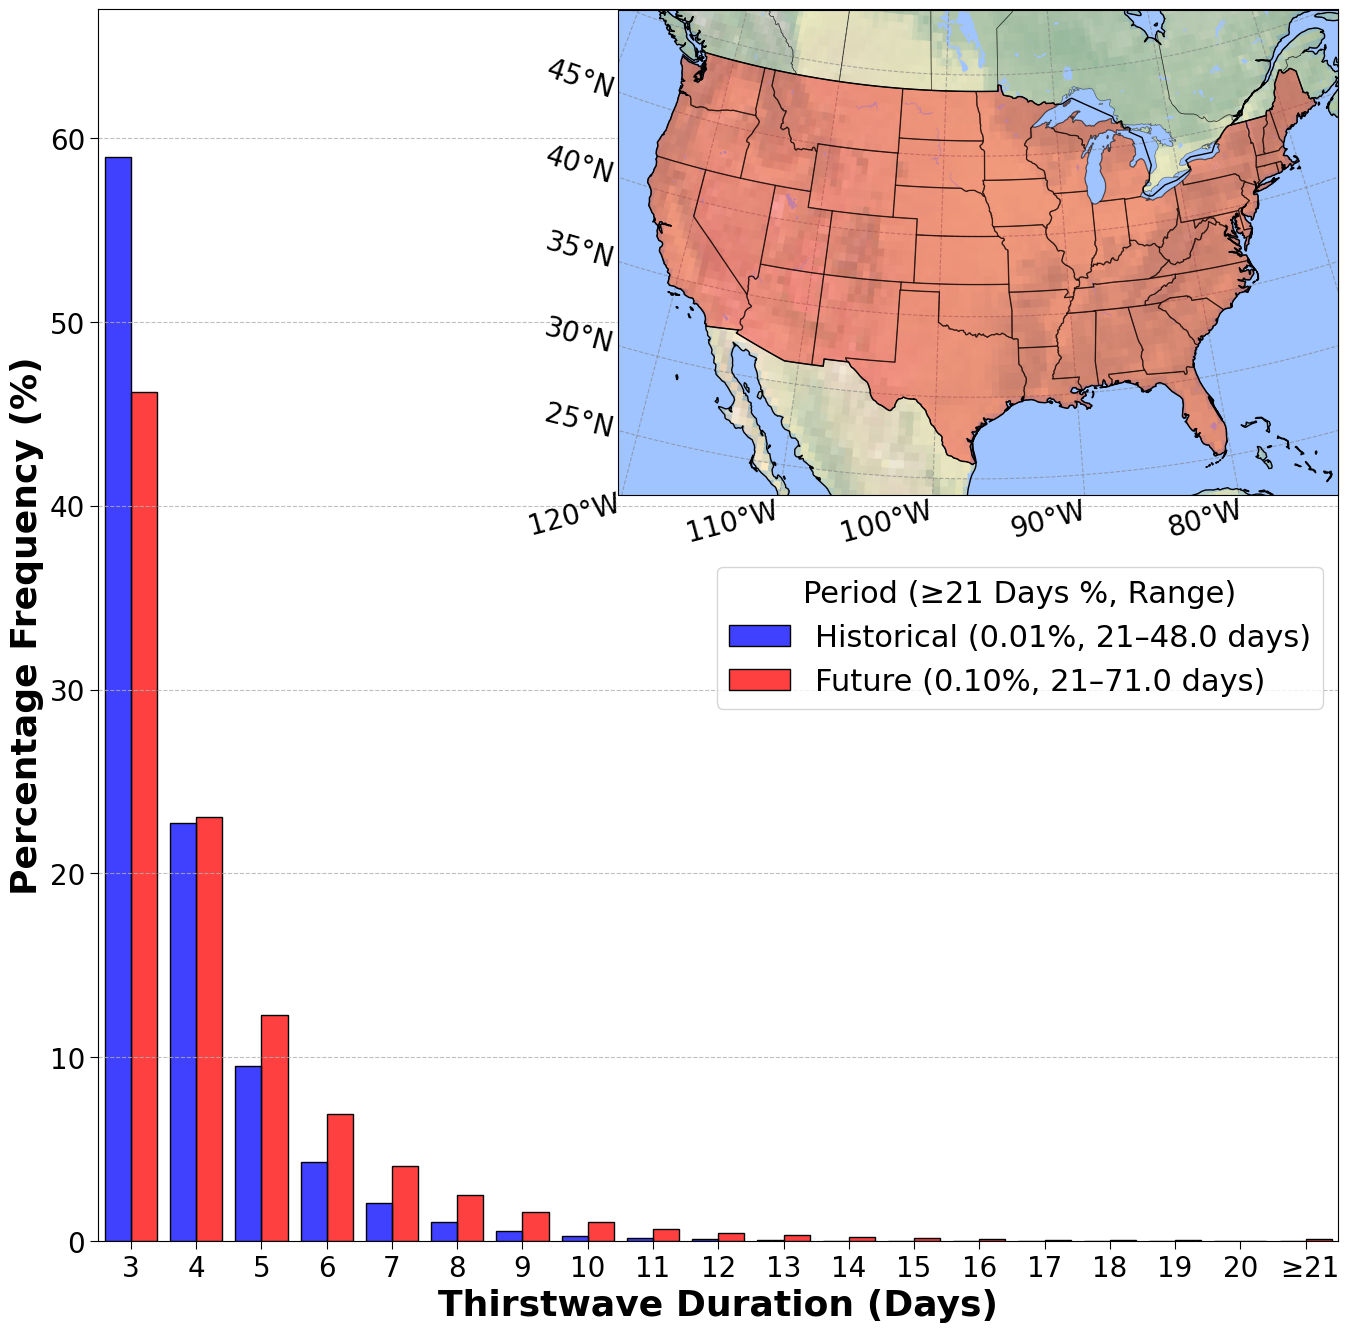

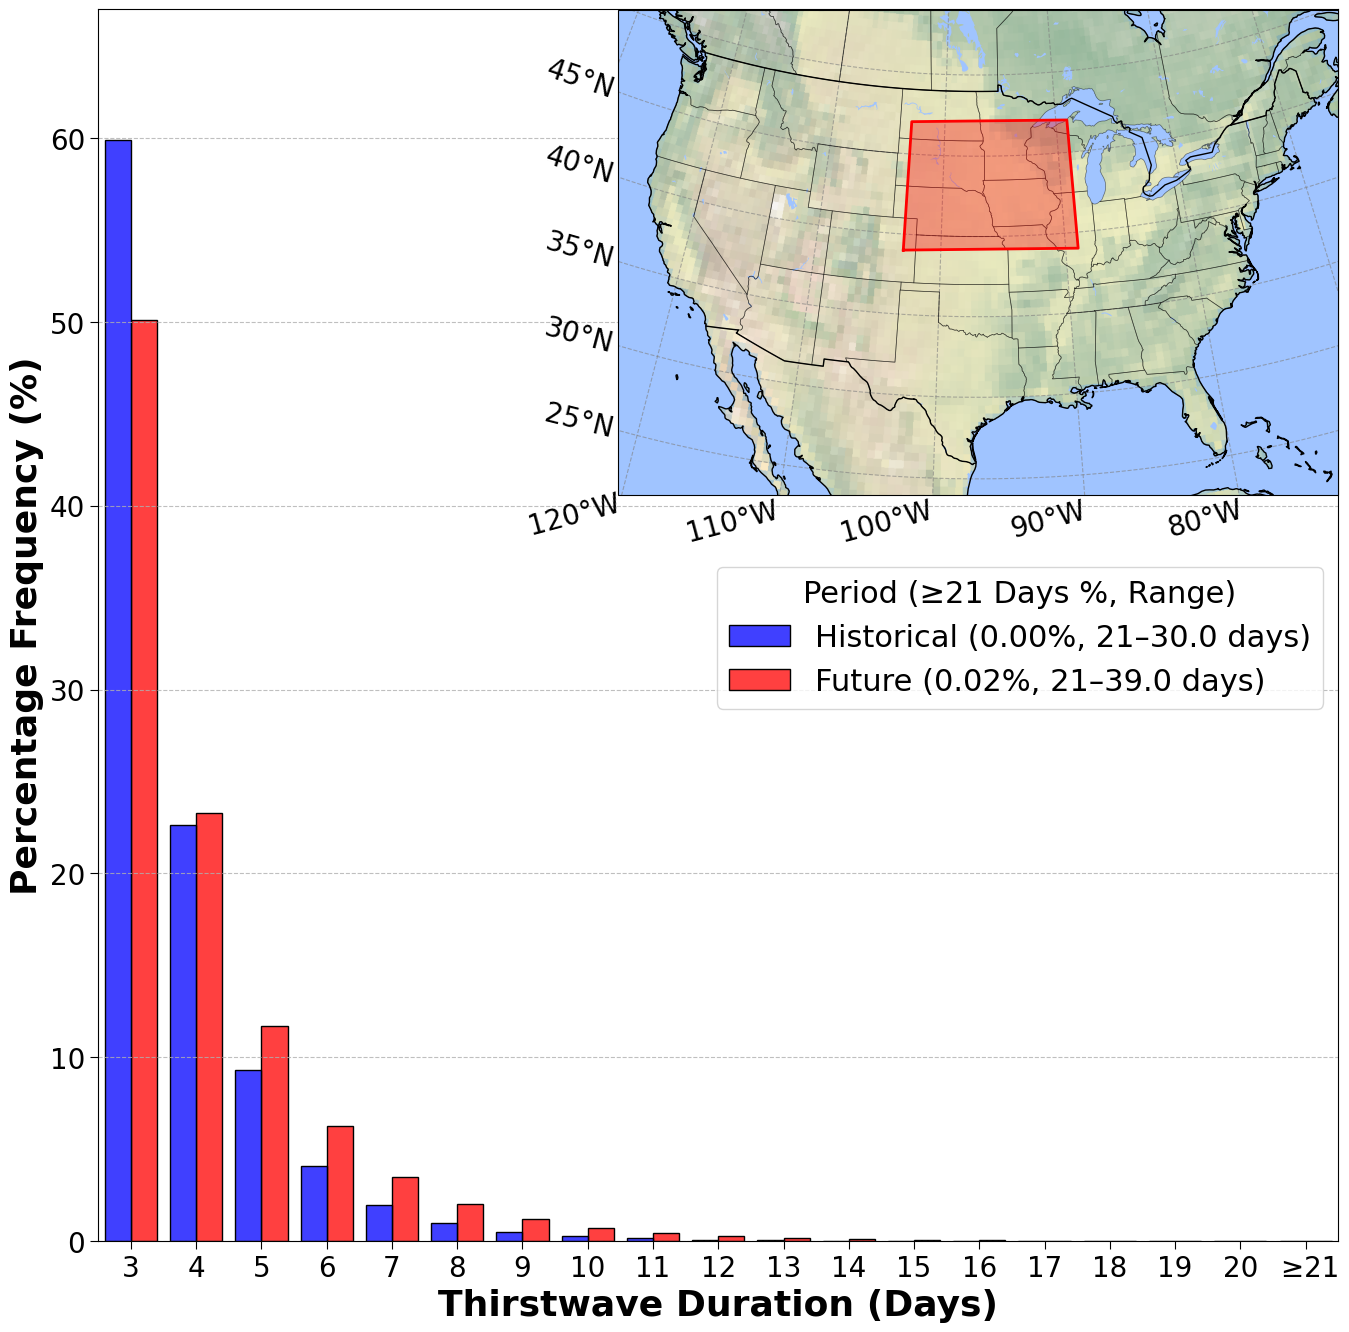

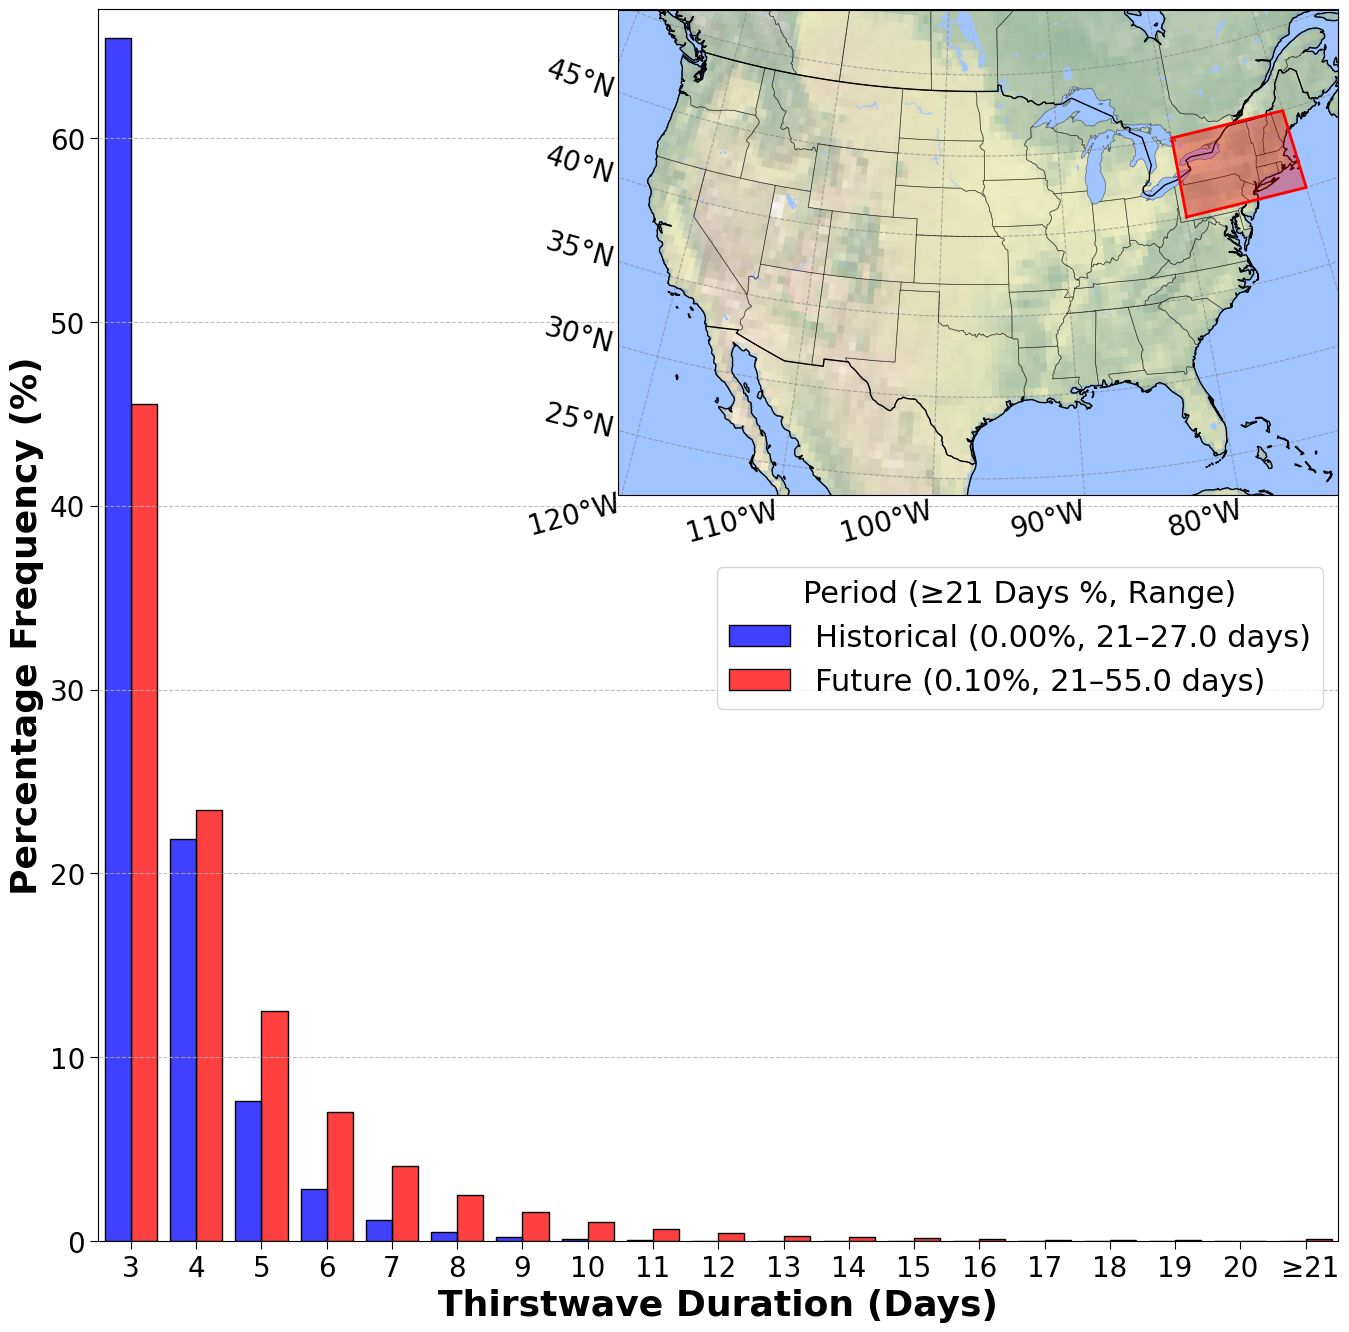

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================================
# 1. DEFINE REGIONS CONFIGURATION
# =========================================================================
regions = [
    {
        "name": "CONUS",
        "save_name": "duration_CONUS_distribution.png",
        "title": "CONUS: Historical vs. Future Duration Distribution Percentage",
        "is_conus": True,
        "lat_s": None,
        "lat_n": None,
        "lon_w": None,
        "lon_e": None,
    },
    {
        "name": "Midwest",
        "save_name": "duration_MIDWEST_distribution.png",
        "title": "Midwest: Historical vs. Future Duration Distribution Percentage",
        "is_conus": False,
        "lat_s": 39,
        "lat_n": 47,
        "lon_w": -103,
        "lon_e": -89,
    },
    {
        "name": "Northeast",
        "save_name": "duration_NE_distribution.png",
        "title": "Northeast: Historical vs. Future Duration Distribution Percentage",
        "is_conus": False,
        "lat_s": 40,
        "lat_n": 45,
        "lon_w": -80,
        "lon_e": -70,
    },
]


def slice_spatial_box(df, s=None, n=None, w=None, e=None):
    """Filter dataframe by latitude and longitude bounds.

    Returns full DataFrame if bounds are None (e.g. for CONUS).
    """
    if s is None or n is None or w is None or e is None:
        return df.copy()

    w_neg, e_neg = -abs(w), -abs(e)
    w_360, e_360 = w_neg % 360, e_neg % 360

    lat_mask = (df["lat"] >= s) & (df["lat"] <= n)
    lon_mask = ((df["lon"] >= w_neg) & (df["lon"] <= e_neg)) | (
        (df["lon"] >= w_360) & (df["lon"] <= e_360)
    )

    return df[lat_mask & lon_mask].copy()


# =========================================================================
# 2. PRE-PROCESS DATA & CALCULATE GLOBAL Y-AXIS LIMITS
# =========================================================================
processed_regions = []
global_max_y = 0

# Cache CONUS geometry once for the CONUS inset map
shpfilename = shpreader.natural_earth(
    resolution="50m", category="cultural", name="admin_1_states_provinces_lakes"
)
reader = shpreader.Reader(shpfilename)
conus_geometries = [
    state.geometry
    for state in reader.records()
    if state.attributes["admin"] == "United States of America"
    and state.attributes["postal"]
    not in ["AK", "HI", "PR", "VI", "GU", "MP", "AS"]
]

for reg in regions:
    # Slice data for the region (or return full set if CONUS)
    df_hist = slice_spatial_box(
        df_dur_hist_conus, reg["lat_s"], reg["lat_n"], reg["lon_w"], reg["lon_e"]
    )
    df_ftr = slice_spatial_box(
        df_dur_ftr_conus, reg["lat_s"], reg["lat_n"], reg["lon_w"], reg["lon_e"]
    )

    df_hist["Period"] = "Historical"
    df_ftr["Period"] = "Future"
    df_combined = pd.concat([df_hist, df_ftr], ignore_index=True)

    # Capping at 21 days for overflow bin
    df_combined["duration_capped"] = np.minimum(df_combined["duration"], 21)

    # Calculate statistics for >= 21 days overflow bin per period
    stats = {}
    for period in ["Historical", "Future"]:
        sub_df = df_combined[df_combined["Period"] == period]
        total_count = len(sub_df)

        if total_count > 0:
            ge_21_count = len(sub_df[sub_df["duration"] >= 21])
            pct_ge_21 = (ge_21_count / total_count) * 100
            max_val = sub_df["duration"].max()
            stats[period] = {
                "pct": pct_ge_21,
                "max": max_val,
                "label": f"{period} ({pct_ge_21:.2f}%, 21–{max_val:.1f} days)",
            }
        else:
            stats[period] = {
                "pct": 0.0,
                "max": 21.0,
                "label": f"{period} (0.00%, 21–21.0 days)",
            }

    # Determine maximum percentage height across all capped bars
    for period in ["Historical", "Future"]:
        sub_data = df_combined[df_combined["Period"] == period][
            "duration_capped"
        ]
        if len(sub_data) > 0:
            counts = sub_data.value_counts(normalize=True) * 100
            if len(counts) > 0:
                global_max_y = max(global_max_y, counts.max())

    processed_regions.append(
        {**reg, "df_combined": df_combined, "stats": stats}
    )

# Calculate standardized percentage boundaries
y_upper_limit = (np.ceil(global_max_y / 5) * 5 + 2) - 5


# =========================================================================
# 3. GENERATE ALL DURATION PLOTS IN LOOP
# =========================================================================
for reg in processed_regions:
    df_comb = reg["df_combined"]
    stats = reg["stats"]

    # Map updated descriptive labels into the DataFrame for Seaborn legend
    df_comb["Period_Label"] = df_comb["Period"].map(
        {
            "Historical": stats["Historical"]["label"],
            "Future": stats["Future"]["label"],
        }
    )

    fig = plt.figure(figsize=(16, 16))

    # --- Discrete Histogram Plot ---
    palette_dict = {
        stats["Historical"]["label"]: "blue",
        stats["Future"]["label"]: "red",
    }

    ax = sns.histplot(
        data=df_comb,
        x="duration_capped",
        hue="Period_Label",
        stat="percent",
        discrete=True,  # Discrete integer bins
        common_norm=False,
        multiple="dodge",
        palette=palette_dict,
        edgecolor="black",
        shrink=0.8,
    )

    # Ticks every 2 days up to 21
    major_ticks = np.arange(3, 22, 1)
    if 21 not in major_ticks:
        major_ticks = np.append(major_ticks, 21)

    # Replace '21' tick label with '≥21'
    tick_labels = [str(t) if t < 21 else " ≥21" for t in major_ticks]

    ax.set_xticks(major_ticks)
    ax.set_xticklabels(tick_labels)

    # Add minor ticks for every day between 3 and 21
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    ax.tick_params(axis="both", which="major", labelsize=20, length=6)
    ax.tick_params(axis="x", which="minor", length=4, width=1.0)

    # X-limits locked from 2.5 to 21.5
    plt.xlim(2.5, 21.5)
    plt.ylim(0, y_upper_limit)

    # Labels and Grid
    plt.xlabel("Thirstwave Duration (Days)", fontsize=26, fontweight="bold")
    plt.ylabel("Percentage Frequency (%)", fontsize=26, fontweight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.8)

    # Move Legend with custom title
    sns.move_legend(
        ax,
        loc="upper right",
        bbox_to_anchor=(1, 0.56),
        fontsize=22,
        title="Period (≥21 Days %, Range)",
        title_fontsize=22,
        frameon=True,
    )

    # --- Add Cartopy Inset Map ---
    map_crs = ccrs.LambertConformal(central_longitude=-97, central_latitude=40)
    ax_inset = fig.add_axes(
        [0.45, 0.503, 0.45, 0.45], projection=map_crs, zorder=5
    )
    ax_inset.set_extent([-121, -73, 24, 52], crs=ccrs.PlateCarree())

    ax_inset.stock_img()
    ax_inset.add_feature(
        cfeature.OCEAN.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )
    ax_inset.add_feature(
        cfeature.LAKES.with_scale("50m"), facecolor="#a0c4ff", zorder=2
    )

    # Handle inset map highlight: Entire CONUS red vs. Regional Box
    if reg["is_conus"]:
        ax_inset.add_geometries(
            conus_geometries,
            crs=ccrs.PlateCarree(),
            facecolor="red",
            edgecolor="black",
            linewidth=1,
            alpha=0.35,
            zorder=3,
        )
    else:
        box_lons = [
            reg["lon_w"],
            reg["lon_e"],
            reg["lon_e"],
            reg["lon_w"],
            reg["lon_w"],
        ]
        box_lats = [
            reg["lat_s"],
            reg["lat_s"],
            reg["lat_n"],
            reg["lat_n"],
            reg["lat_s"],
        ]

        ax_inset.fill(
            box_lons,
            box_lats,
            color="red",
            alpha=0.35,
            transform=ccrs.PlateCarree(),
            zorder=6,
        )
        ax_inset.plot(
            box_lons,
            box_lats,
            color="red",
            linewidth=2,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=7,
        )

    # Cartopy Boundaries & Features
    all_states = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lakes",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.5,
        zorder=3,
    )
    ax_inset.add_feature(all_states)

    countries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_0_boundary_lines_land",
        scale="50m",
        facecolor="none",
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )
    ax_inset.add_feature(countries)
    ax_inset.add_feature(
        cfeature.COASTLINE.with_scale("50m"),
        edgecolor="black",
        linewidth=1,
        zorder=4,
    )

    gl = ax_inset.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--",
        zorder=5,
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 4
    gl.ypadding = 4
    gl.xlabel_style = {"size": 20, "color": "black", "rotation": 15}
    gl.ylabel_style = {"size": 20, "color": "black"}
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    plt.savefig(reg["save_name"], dpi=300, bbox_inches="tight")
    plt.show()